Average Accuracy: 0.7408284525931585
Average Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.74      0.76       100
           1       0.57      0.63      0.60        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       100
           1       0.73      0.70      0.72        54

    accuracy                           0.81       154
   macro avg       0.79      0.78      0.78       154
weighted avg       0.80      0.81      0.80       154

              precision    recall  f1-score   support

           0       0.84      0.78      0.81       100
           1       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weigh

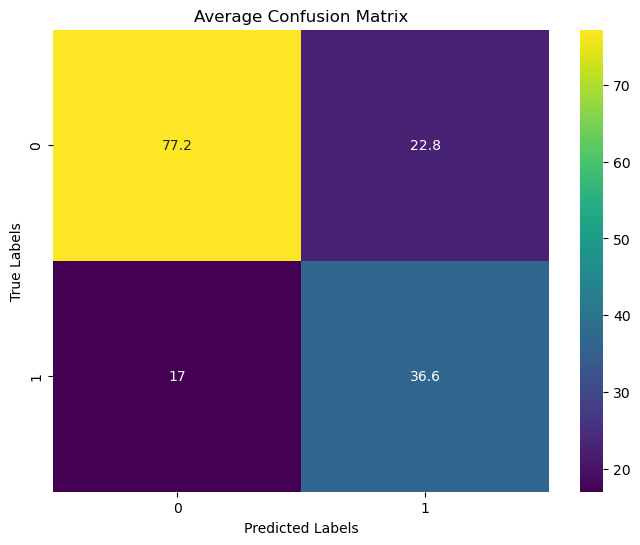

In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
dataset = pd.read_csv('diabetes.csv')

# Features
x = dataset.drop(['Outcome'], axis=1)

# Target
y = dataset['Outcome']

# Initialize StratifiedKFold with k=5
k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Initialize Gaussian Naive Bayes classifier
classifier_nb = GaussianNB()

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Lists to store performance metrics across folds
accuracy_list = []
classification_reports = []
confusion_matrices = []

# Perform k-fold cross-validation
for train_index, test_index in k_fold.split(x, y):
    # Split data
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Scaling
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    # Data augmentation using SMOTE
    x_train_resampled, y_train_resampled = smote.fit_resample(x_train_scaled, y_train)

    # Train the model
    classifier_nb.fit(x_train_resampled, y_train_resampled)

    # Predict target of test data based on test data target
    y_pred = classifier_nb.predict(x_test_scaled)

    # Performance metrics
    accuracy = metrics.accuracy_score(y_test, y_pred)
    classification_report_str = classification_report(y_test, y_pred)
    confusion_matrix_arr = confusion_matrix(y_test, y_pred)

    # Store metrics in lists
    accuracy_list.append(accuracy)
    classification_reports.append(classification_report_str)
    confusion_matrices.append(confusion_matrix_arr)

# Print average accuracy across folds
print("Average Accuracy:", sum(accuracy_list) / len(accuracy_list))

# Print average classification report across folds
avg_classification_report = "\n".join(classification_reports)
print("Average Classification Report:\n", avg_classification_report)

# Average confusion matrix
avg_conf_matrix = sum(confusion_matrices) / len(confusion_matrices)

# Plotting the average confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(avg_conf_matrix, annot=True, fmt='g', cmap='viridis')
plt.title('Average Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
